# 07 - Experimental BERT Embeddings + Random Forest

This notebook implements an **experimental comparison** model for the 5-class document classification task:
- invoice
- form
- resume
- email
- budget

Compliance notes:
- Non-generative workflow.
- BERT is used **only as a frozen encoder** to produce embeddings.
- No prompting, no text generation, no LLM inference loop.
- This notebook is experimental and should not replace the official classical pipeline if transformer-based methods are disallowed in final submission.


## 1) Repository Inspection and Existing Assets

Before training, we inspect the repository and verify available assets:
- dataset split files
- OCR cache and loaders
- layout feature tables
- existing prediction output format
- reusable source modules


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)

inspect_targets = {
    'notebooks': PROJECT_ROOT / 'notebooks',
    'src': PROJECT_ROOT / 'src',
    'data_processed': PROJECT_ROOT / 'data' / 'processed',
    'data_interim': PROJECT_ROOT / 'data' / 'interim',
    'models': PROJECT_ROOT / 'models',
    'outputs': PROJECT_ROOT / 'outputs',
    'reports': PROJECT_ROOT / 'reports',
}

for name, path in inspect_targets.items():
    print('\n===', name, '===')
    if not path.exists():
        print('Missing:', path)
        continue
    entries = sorted([p.name for p in path.iterdir()])
    for e in entries[:40]:
        print('-', e)
    if len(entries) > 40:
        print(f'... ({len(entries)-40} more)')


PROJECT_ROOT: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification

=== notebooks ===
- 00_dataset_download_and_preparation.ipynb
- 01_ocr_pipeline_build_and_validation.ipynb
- 02_ocr_text_plus_layout_features.ipynb
- 02b_confusion_pair_improvement.ipynb
- 05_invoice_extraction_and_evaluation.ipynb
- 07_bert_random_forest.ipynb
- data
- outputs

=== src ===
- __init__.py
- __pycache__
- config.py
- evaluation.py
- image_preprocessing.py
- invoice_extraction.py
- invoice_rules.py
- layout_features.py
- models_bert_rf.py
- models_layout.py
- ocr_engine.py
- utils.py
- validators.py
- zones.py

=== data_processed ===
- class_balance_by_split.csv
- dataset_summary.json
- duplicates_by_hash.csv
- duplicates_by_relative_path.csv
- five_class_subset
- metadata_all.csv
- metadata_five_classes.csv
- test.csv
- train.csv
- val.csv

=== data_interim ===
- layout_features
- ocr
- ocr_mode_eval

=== models ===
- layout

=== outputs ===
- comparisons
- extrac

### Inspection Summary

Expected existing assets (checked by code above):
- `notebooks/00_dataset_download_and_preparation.ipynb`
- `notebooks/01_ocr_pipeline_build_and_validation.ipynb`
- `src/ocr_engine.py`
- `src/evaluation.py`
- `data/processed/train.csv`, `val.csv`, `test.csv`
- OCR cache under `data/interim/ocr/`
- optional layout tables under `data/interim/layout_features/`


## 2) Imports and Setup


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_ocr_config
from src.ocr_engine import load_ocr_text
from src.evaluation import (
    compute_metrics,
    metrics_dict_to_frame,
    confusion_matrix_df,
    classification_report_df,
    plot_confusion_matrix,
)
from src.models_bert_rf import (
    check_transformers_stack,
    encode_texts_with_bert,
    load_embedding_cache,
    save_embedding_cache,
    build_aux_feature_tables,
    fit_aux_preprocessor,
    transform_aux_features,
    build_combined_matrix,
    train_random_forest,
    predict_labels_and_proba,
    build_prediction_table,
    save_artifact,
)


In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
LABELS = ['invoice', 'form', 'resume', 'email', 'budget']

cfg = load_ocr_config(PROJECT_ROOT / 'configs' / 'config.yaml')
cfg.cache_dir = str(PROJECT_ROOT / 'data' / 'interim' / 'ocr')

models_dir = PROJECT_ROOT / 'models' / 'experimental'
pred_dir = PROJECT_ROOT / 'outputs' / 'predictions'
fig_dir = PROJECT_ROOT / 'reports' / 'figures'
table_dir = PROJECT_ROOT / 'reports' / 'tables'
embed_dir = PROJECT_ROOT / 'data' / 'interim' / 'bert_embeddings'

for p in [models_dir, pred_dir, fig_dir, table_dir, embed_dir]:
    p.mkdir(parents=True, exist_ok=True)

print('Artifacts will be saved under:')
print(' -', models_dir)
print(' -', pred_dir)
print(' -', fig_dir)
print(' -', table_dir)
print(' -', embed_dir)


Artifacts will be saved under:
 - /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental
 - /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/predictions
 - /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/figures
 - /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/tables
 - /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/interim/bert_embeddings


## 3) Load Train/Validation/Test Metadata


In [4]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train.csv')
val_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val.csv')
test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test.csv')

required_cols = {'doc_id', 'file_path', 'class_name'}
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'{split_name}.csv missing required columns: {missing}')
    if 'split' not in df.columns:
        df['split'] = split_name

print('Train size:', len(train_df))
print('Val size:', len(val_df))
print('Test size:', len(test_df))

print('\nClass balance by split:')
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print('\n', split_name)
    print(df['class_name'].value_counts())


Train size: 8777
Val size: 1882
Test size: 1881

Class balance by split:

 train
class_name
resume     1775
email      1761
form       1754
budget     1753
invoice    1734
Name: count, dtype: int64

 val
class_name
resume     381
email      378
form       376
budget     376
invoice    371
Name: count, dtype: int64

 test
class_name
resume     380
email      377
form       376
budget     376
invoice    372
Name: count, dtype: int64


## 4) Load OCR Text from Shared OCR Cache

We reuse the shared OCR pipeline outputs (`src/ocr_engine.py`) and do not rerun OCR here.


In [5]:
def attach_ocr_text(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['ocr_text'] = out['doc_id'].map(lambda d: load_ocr_text(d, cfg=cfg))
    out['ocr_text'] = out['ocr_text'].fillna('').astype(str)
    out['ocr_text'] = out['ocr_text'].map(lambda t: ' '.join(t.split()))
    return out

train_text_df = attach_ocr_text(train_df)
val_text_df = attach_ocr_text(val_df)
test_text_df = attach_ocr_text(test_df)

empty_train = (train_text_df['ocr_text'].str.len() == 0).mean()
empty_val = (val_text_df['ocr_text'].str.len() == 0).mean()
empty_test = (test_text_df['ocr_text'].str.len() == 0).mean()

print('Empty OCR ratio (train/val/test):', round(empty_train, 4), round(empty_val, 4), round(empty_test, 4))
train_text_df[['doc_id', 'class_name', 'ocr_text']].head(3)


Empty OCR ratio (train/val/test): 0.0014 0.0011 0.0021


,doc_id,class_name,ocr_text
0,doc_00000000,form,POA oN ZAphS yKennie wonaray USA. PHILIP MORRI...
1,doc_00000001,form,ot oon - sah wed . C}; cnr narave tutor cows “...
2,doc_00000002,form,". SurTGog . e- . 5093 . |, sersene MALL CRC co..."


## 5) Optional Auxiliary Layout/Metadata Features

If layout summary feature tables already exist, we reuse them and merge by `doc_id`.


In [6]:
USE_AUX_FEATURES = True
aux_feature_cols = []

if USE_AUX_FEATURES:
    try:
        train_aux, val_aux, test_aux, aux_feature_cols = build_aux_feature_tables(
            train_text_df,
            val_text_df,
            test_text_df,
            layout_feature_dir=PROJECT_ROOT / 'data' / 'interim' / 'layout_features',
        )
        print('Loaded auxiliary feature columns:', len(aux_feature_cols))
        print(aux_feature_cols)
    except Exception as exc:
        print('Could not load layout feature tables. Continuing without aux features.')
        print('Reason:', exc)
        USE_AUX_FEATURES = False


Loaded auxiliary feature columns: 13
['image_width', 'image_height', 'aspect_ratio', 'num_words', 'num_lines', 'numeric_token_ratio', 'currency_token_count', 'date_like_token_count', 'invoice_anchor_count', 'budget_anchor_count', 'resume_anchor_count', 'email_anchor_count', 'form_anchor_count']


## 6) BERT Encoder Availability Check


In [9]:
ok, msg = check_transformers_stack()
print(msg)
if not ok:
    raise ImportError(
        'transformers/torch is not available in this environment. '
        'Install: pip install transformers torch sentencepiece\n'
        'Then rerun this notebook.'
    )


/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers/torch available


## 7) Build (or Load) BERT Embeddings

Default setup:
- model: `bert-base-uncased`
- frozen encoder
- mean pooling
- embeddings cached by split in `data/interim/bert_embeddings/`


In [10]:
BERT_MODEL_NAME = 'bert-base-uncased'
POOLING = 'mean'   # 'mean' or 'cls'
MAX_LENGTH = 256
BATCH_SIZE = 16
NORMALIZE_EMB = False
FORCE_RECOMPUTE_EMB = False


def get_or_create_embeddings(df: pd.DataFrame, split: str):
    cache_path = embed_dir / f'bert_{BERT_MODEL_NAME.replace("/", "_")}_{POOLING}_{split}.npz'
    cache = load_embedding_cache(cache_path)

    if cache is not None and not FORCE_RECOMPUTE_EMB:
        cached_doc_ids, cached_emb = cache
        cached_doc_ids = cached_doc_ids.astype(str)

        # Ensure cache aligns with current split order; if not, rebuild.
        if len(cached_doc_ids) == len(df) and np.all(cached_doc_ids == df['doc_id'].astype(str).values):
            print(f'[{split}] cache hit:', cache_path.name)
            return cached_emb
        print(f'[{split}] cache mismatch; rebuilding embeddings...')

    print(f'[{split}] encoding with BERT... this can take time')
    emb = encode_texts_with_bert(
        df['ocr_text'].tolist(),
        model_name=BERT_MODEL_NAME,
        pooling=POOLING,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH,
        normalize=NORMALIZE_EMB,
    )
    save_embedding_cache(
        cache_path,
        doc_ids=df['doc_id'].astype(str).tolist(),
        embeddings=emb,
        meta={
            'model_name': BERT_MODEL_NAME,
            'pooling': POOLING,
            'max_length': MAX_LENGTH,
            'batch_size': BATCH_SIZE,
            'normalize': NORMALIZE_EMB,
            'split': split,
        },
    )
    return emb

X_emb_train = get_or_create_embeddings(train_text_df, 'train')
X_emb_val = get_or_create_embeddings(val_text_df, 'val')
X_emb_test = get_or_create_embeddings(test_text_df, 'test')

print('Embedding shapes:', X_emb_train.shape, X_emb_val.shape, X_emb_test.shape)


[train] encoding with BERT... this can take time
[val] encoding with BERT... this can take time
[test] encoding with BERT... this can take time
Embedding shapes: (8777, 768) (1882, 768) (1881, 768)


## 8) Build Combined Feature Matrix (BERT + Optional Aux)

Leakage safety:
- if aux preprocessing is used (imputer/scaler), it is fit on **train only**.


In [11]:
if USE_AUX_FEATURES and len(aux_feature_cols) > 0:
    aux_imputer, aux_scaler = fit_aux_preprocessor(train_aux, aux_feature_cols)

    X_aux_train = transform_aux_features(train_aux, aux_feature_cols, aux_imputer, aux_scaler)
    X_aux_val = transform_aux_features(val_aux, aux_feature_cols, aux_imputer, aux_scaler)
    X_aux_test = transform_aux_features(test_aux, aux_feature_cols, aux_imputer, aux_scaler)

    X_train = build_combined_matrix(X_emb_train, X_aux_train)
    X_val = build_combined_matrix(X_emb_val, X_aux_val)
    X_test = build_combined_matrix(X_emb_test, X_aux_test)
else:
    aux_imputer, aux_scaler = None, None
    X_train, X_val, X_test = X_emb_train, X_emb_val, X_emb_test


y_train = train_text_df['class_name'].values
y_val = val_text_df['class_name'].values
y_test = test_text_df['class_name'].values

print('Final matrix shapes:', X_train.shape, X_val.shape, X_test.shape)


Final matrix shapes: (8777, 781) (1882, 781) (1881, 781)


## 9) Train Random Forest (Validation-Driven Selection)

We tune RF hyperparameters on validation only. Test remains untouched.


In [12]:
rf_grid = [
    {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 700, 'max_depth': 60, 'min_samples_leaf': 1},
    {'n_estimators': 800, 'max_depth': 80, 'min_samples_leaf': 2},
]

search_rows = []
best = None

for cfg_rf in rf_grid:
    clf = train_random_forest(
        X_train,
        y_train,
        random_state=RANDOM_STATE,
        n_estimators=cfg_rf['n_estimators'],
        max_depth=cfg_rf['max_depth'],
        min_samples_leaf=cfg_rf['min_samples_leaf'],
        class_weight='balanced_subsample',
    )

    y_val_pred, p_val = predict_labels_and_proba(clf, X_val)
    m_val = compute_metrics(y_val, y_val_pred, LABELS)

    row = {
        **cfg_rf,
        'val_accuracy': m_val['accuracy'],
        'val_macro_f1': m_val['macro_f1'],
        'val_invoice_recall': m_val['invoice_recall'],
    }
    search_rows.append(row)

    score = m_val['macro_f1']
    if best is None or score > best['score']:
        best = {
            'score': score,
            'model': clf,
            'config': cfg_rf,
            'y_val_pred': y_val_pred,
            'p_val': p_val,
            'val_metrics': m_val,
        }

rf_search_df = pd.DataFrame(search_rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
rf_search_df


,n_estimators,max_depth,min_samples_leaf,val_accuracy,val_macro_f1,val_invoice_recall
0,700,60.0,1,0.824655,0.825324,0.760108
1,600,NaN,1,0.823061,0.823642,0.765499
2,400,NaN,1,0.819341,0.820063,0.765499
3,800,80.0,2,0.818278,0.819019,0.768194


## 10) Validation Evaluation


In [13]:
print('Best RF config (selected on validation):', best['config'])
val_metrics = best['val_metrics']
metrics_dict_to_frame(val_metrics, 'bert_rf', 'val')


Best RF config (selected on validation): {'n_estimators': 700, 'max_depth': 60, 'min_samples_leaf': 1}


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,bert_rf,val,0.824655,0.825324,0.826001,0.740157,0.760108,0.799419,0.731383,0.994536,0.955381,0.906166,0.89418,0.700957,0.779255,0.740157,0.760108


## 11) Final Test Evaluation


In [14]:
best_model = best['model']
y_test_pred, p_test = predict_labels_and_proba(best_model, X_test)
test_metrics = compute_metrics(y_test, y_test_pred, LABELS)

test_metrics_df = metrics_dict_to_frame(test_metrics, 'bert_rf', 'test')
test_metrics_df


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,bert_rf,test,0.814992,0.815383,0.815939,0.716113,0.752688,0.770833,0.68883,0.989071,0.952632,0.917333,0.912467,0.697337,0.765957,0.716113,0.752688


## 12) Confusion Matrix and Per-Class Report


,invoice,form,resume,email,budget
invoice,280,28,0,4,60
form,44,259,3,21,49
resume,5,5,362,3,5
email,6,16,0,344,11
budget,56,28,1,3,288


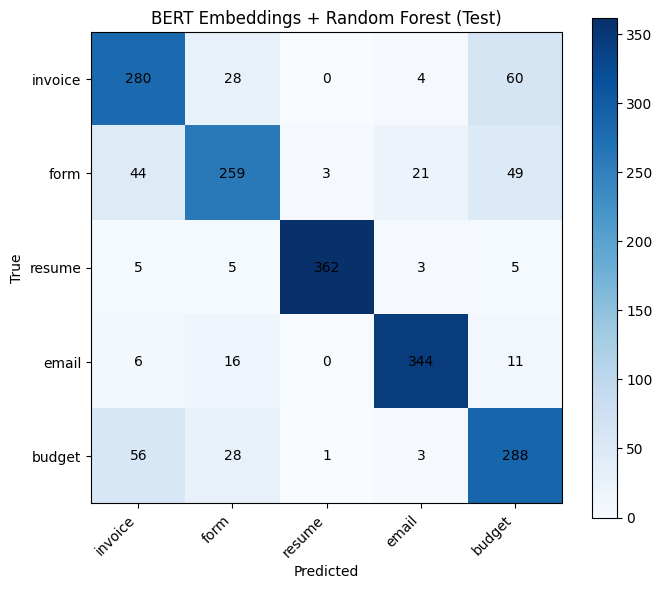

In [15]:
cm_test = confusion_matrix_df(y_test, y_test_pred, LABELS)
plot_confusion_matrix(
    cm_test,
    title='BERT Embeddings + Random Forest (Test)',
    save_path=fig_dir / 'bert_rf_confusion_matrix.png',
)
cm_test


In [16]:
cls_report_test = classification_report_df(y_test, y_test_pred, LABELS)
cls_report_test


,precision,recall,f1-score,support
invoice,0.716113,0.752688,0.733945,372.000000
form,0.770833,0.688830,0.727528,376.000000
resume,0.989071,0.952632,0.970509,380.000000
email,0.917333,0.912467,0.914894,377.000000
budget,0.697337,0.765957,0.730038,376.000000
accuracy,0.814992,0.814992,0.814992,0.814992
macro avg,0.818137,0.814515,0.815383,1881.000000
weighted avg,0.818771,0.814992,0.815939,1881.000000


## 13) Invoice Recall Comparison

We compare invoice recall against existing model outputs if they are available in `outputs/predictions/`.


In [17]:
comparison_rows = [
    {'model_name': 'bert_rf', 'invoice_recall': test_metrics['invoice_recall'], 'macro_f1': test_metrics['macro_f1'], 'accuracy': test_metrics['accuracy']}
]

candidate_files = [
    'text_only_test_predictions.csv',
    'text_layout_test_predictions.csv',
    'layout_only_test_predictions.csv',
    '02b_text_only_plus_specialist_test_predictions.csv',
    '02c_text_only_dual_specialist_test_predictions.csv',
]

for fn in candidate_files:
    fp = pred_dir / fn
    if not fp.exists():
        continue
    dfp = pd.read_csv(fp)
    if not {'true_label', 'pred_label'}.issubset(dfp.columns):
        continue
    m = compute_metrics(dfp['true_label'].values, dfp['pred_label'].values, LABELS)
    comparison_rows.append({
        'model_name': fn.replace('_test_predictions.csv', ''),
        'invoice_recall': m['invoice_recall'],
        'macro_f1': m['macro_f1'],
        'accuracy': m['accuracy'],
    })

invoice_comp_df = pd.DataFrame(comparison_rows).sort_values('invoice_recall', ascending=False).reset_index(drop=True)
invoice_comp_df


,model_name,invoice_recall,macro_f1,accuracy
0,text_only,0.841398,0.877511,0.876661
1,02b_text_only_plus_specialist,0.841398,0.877511,0.876661
2,02c_text_only_dual_specialist,0.841398,0.877511,0.876661
3,text_layout,0.817204,0.855609,0.854864
4,layout_only,0.784946,0.810574,0.810207
5,bert_rf,0.752688,0.815383,0.814992


## 14) Discussion: Strengths and Limitations

Suggested interpretation points for this experimental method:
- Strength: contextual embeddings can capture semantics missed by sparse n-grams.
- Strength: RF on top can model non-linear interactions between embedding dimensions and auxiliary features.
- Limitation: heavier runtime and dependency footprint (`transformers`, `torch`).
- Limitation: this approach may conflict with project rules if transformers are disallowed in final official pipeline.
- Practical note: keep this notebook as benchmark/ablation, not default production path unless approved by project constraints.


## 15) Save Artifacts


In [18]:
# Predictions in project-standard format
val_pred_df = build_prediction_table(
    doc_ids=val_text_df['doc_id'].astype(str).tolist(),
    y_true=y_val,
    y_pred=best['y_val_pred'],
    split='val',
    model_name='bert_rf',
    labels=LABELS,
    proba=best['p_val'],
)

test_pred_df = build_prediction_table(
    doc_ids=test_text_df['doc_id'].astype(str).tolist(),
    y_true=y_test,
    y_pred=y_test_pred,
    split='test',
    model_name='bert_rf',
    labels=LABELS,
    proba=p_test,
)

val_pred_df.to_csv(pred_dir / 'bert_rf_val_predictions.csv', index=False)
test_pred_df.to_csv(pred_dir / 'bert_rf_test_predictions.csv', index=False)

# Metrics tables
bert_rf_metrics = pd.concat([
    metrics_dict_to_frame(val_metrics, 'bert_rf', 'val'),
    metrics_dict_to_frame(test_metrics, 'bert_rf', 'test'),
], ignore_index=True)
bert_rf_metrics.to_csv(table_dir / 'bert_rf_metrics.csv', index=False)

cls_report_test.to_csv(table_dir / 'bert_rf_classification_report_test.csv')
rf_search_df.to_csv(table_dir / 'bert_rf_rf_search_val.csv', index=False)
invoice_comp_df.to_csv(table_dir / 'bert_rf_invoice_recall_comparison.csv', index=False)

# Model and preprocessors
save_artifact(best_model, models_dir / 'bert_rf_model.joblib')
save_artifact(best['config'], models_dir / 'bert_rf_model_config.joblib')

if USE_AUX_FEATURES and len(aux_feature_cols) > 0:
    save_artifact(aux_feature_cols, models_dir / 'bert_rf_aux_feature_columns.joblib')
    save_artifact(aux_imputer, models_dir / 'bert_rf_aux_imputer.joblib')
    save_artifact(aux_scaler, models_dir / 'bert_rf_aux_scaler.joblib')

print('Saved artifacts:')
print('-', models_dir / 'bert_rf_model.joblib')
print('-', pred_dir / 'bert_rf_val_predictions.csv')
print('-', pred_dir / 'bert_rf_test_predictions.csv')
print('-', table_dir / 'bert_rf_metrics.csv')
print('-', fig_dir / 'bert_rf_confusion_matrix.png')


Saved artifacts:
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/bert_rf_model.joblib
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/predictions/bert_rf_val_predictions.csv
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/predictions/bert_rf_test_predictions.csv
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/tables/bert_rf_metrics.csv
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/figures/bert_rf_confusion_matrix.png
